**1. Problem defination**

Applying linear regression.To find the relationship between electrical measurements and total power consumption in a household. The target variable selected for prediction is **Global_active_power**, as it represents the total active power consumed at a given time and directly reflects energy usage behavior. The input features chosen for this model include **Voltage, Global_intensity**, and the three sub-metering variables (**Sub_metering_1, Sub_metering_2, Sub_metering_3**), which correspond to energy consumption in specific areas such as kitchen, laundry, and heating systems.

**2. Data Collection & Importing**

Data is colleted from kaggle consists of 799073 columns and 9 rows in a text format(separated by semicolon)

In [206]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [207]:
df = pd.read_csv("household_power_consumption.txt", sep=";")

/tmp/ipykernel_2298/2456779612.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("household_power_consumption.txt", sep=";")


In [208]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [209]:
df.shape

(2075259, 9)

**3. Data Preprocessing & EDA (Exploratory Data Analysis)**


In [210]:
df.info() #Data is in object format(mixed)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    object 
 3   Global_reactive_power  object 
 4   Voltage                object 
 5   Global_intensity       object 
 6   Sub_metering_1         object 
 7   Sub_metering_2         object 
 8   Sub_metering_3         float64
dtypes: float64(1), object(8)
memory usage: 142.5+ MB


In [211]:
df['DateTime'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' + df['Time'].astype(str),
    errors='coerce'
)

/tmp/ipykernel_2298/1993614683.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DateTime'] = pd.to_datetime(


In [212]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [213]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.time

In [214]:
cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Date                   datetime64[ns]
 1   Time                   object        
 2   Global_active_power    float64       
 3   Global_reactive_power  float64       
 4   Voltage                float64       
 5   Global_intensity       float64       
 6   Sub_metering_1         float64       
 7   Sub_metering_2         float64       
 8   Sub_metering_3         float64       
 9   DateTime               datetime64[ns]
dtypes: datetime64[ns](2), float64(7), object(1)
memory usage: 158.3+ MB


In [216]:
df.head() #Data converted into appropriate format

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,DateTime
0,2006-12-16,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,2006-12-16,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,2006-12-16,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,2006-12-16,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,2006-12-16,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [217]:
# Feature Engineering: extracting important features from existing data(column).
df.set_index('DateTime', inplace=True)
df['hour'] = df.index.hour
df['day'] = df.index.day
df['month'] = df.index.month
df['weekday'] = df.index.weekday

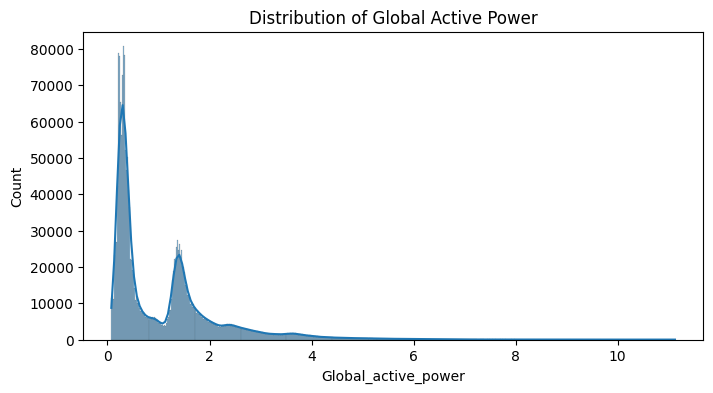

In [218]:
# Understanding the distribution of the data... it is like skewness analysis
plt.figure(figsize=(8,4))
sns.histplot(df['Global_active_power'], kde=True)
plt.title('Distribution of Global Active Power')
plt.show()

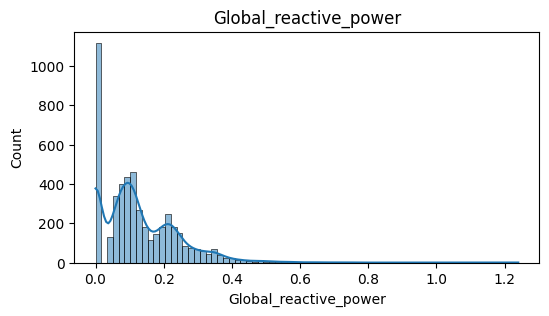

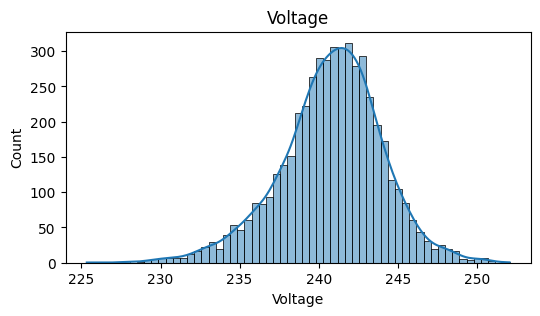

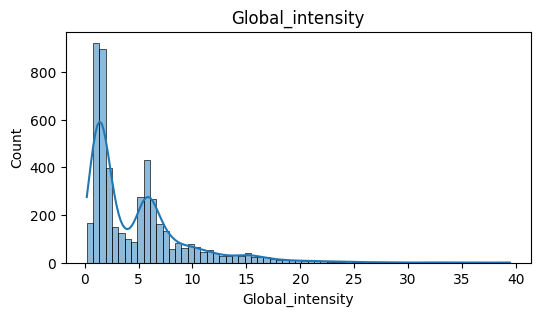

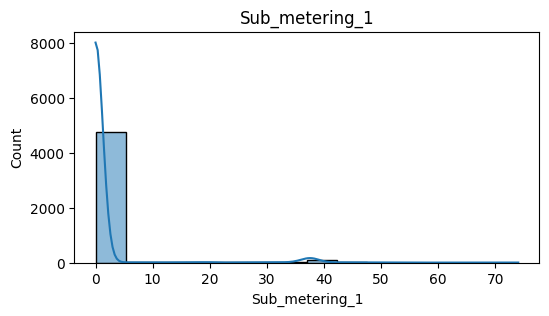

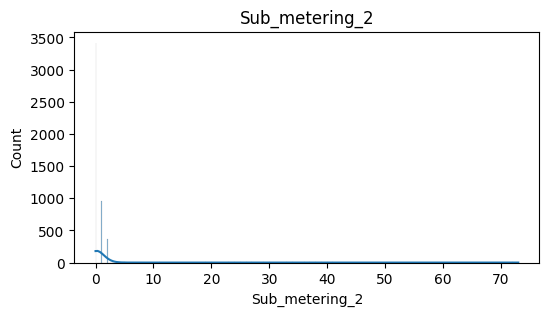

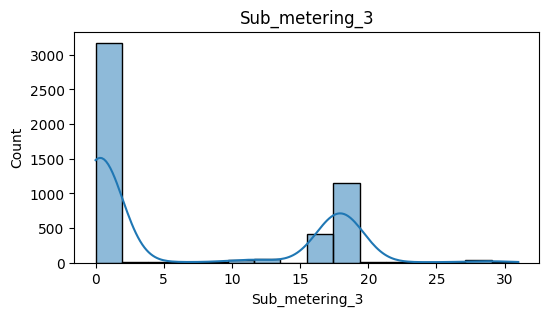

In [219]:
cols = ['Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col].sample(5000), kde=True)
    plt.title(col)
    plt.show()

**Insight from previous data distribution graphs **

* Most features (power, intensity, sub-metering) are heavily right-skewed,


* Voltage is stable and normally distributed

* Sub-metering features are sparse (many zeros), meaning certain appliances are used infrequently.


In [220]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979
hour,0


In [221]:
df = df.dropna() # Deleting the missing rows is better because the dataset is too large
                  # removing 25979 rows is nregligible

In [222]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0
hour,0


In [223]:
# Checking duplicates
df.duplicated().sum()

np.int64(0)

In [224]:
# There are no duplicates present in the dataset

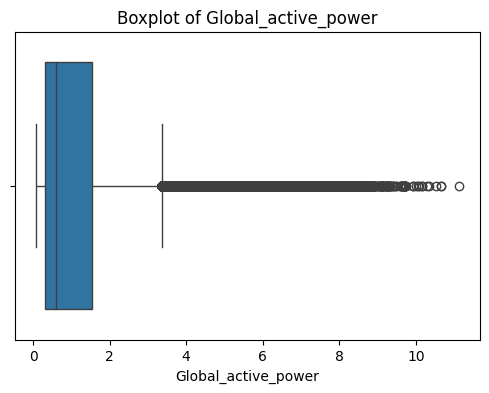

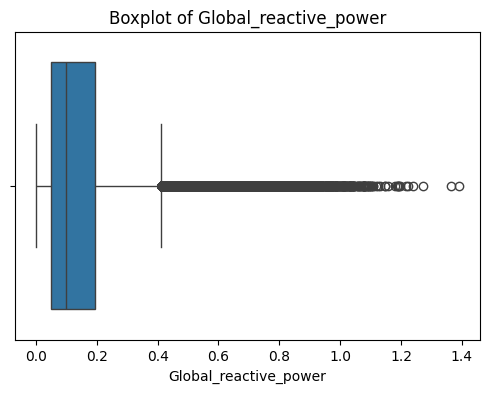

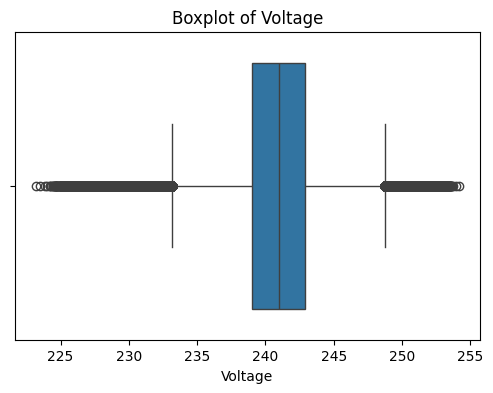

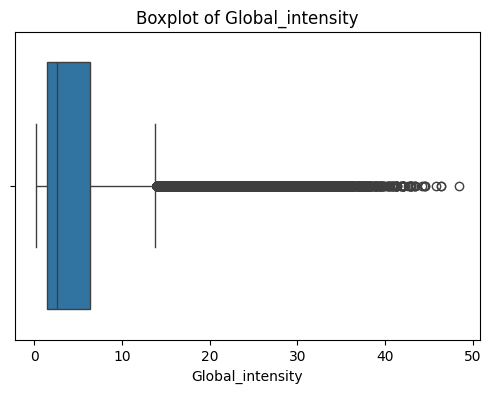

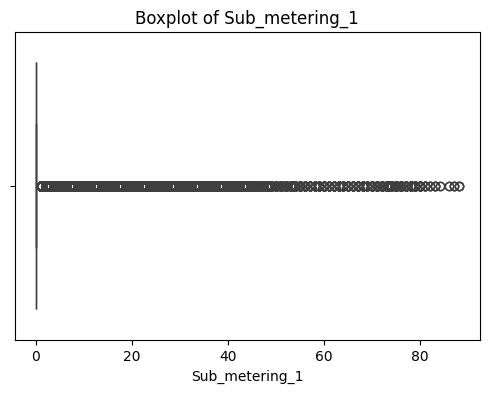

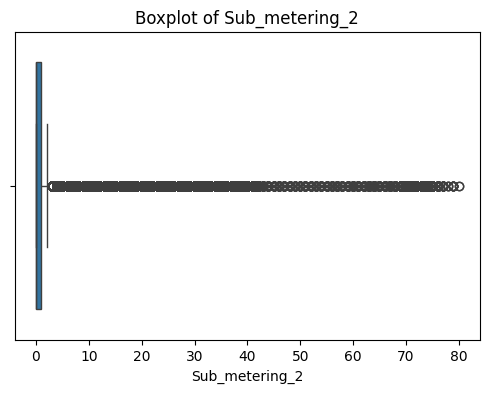

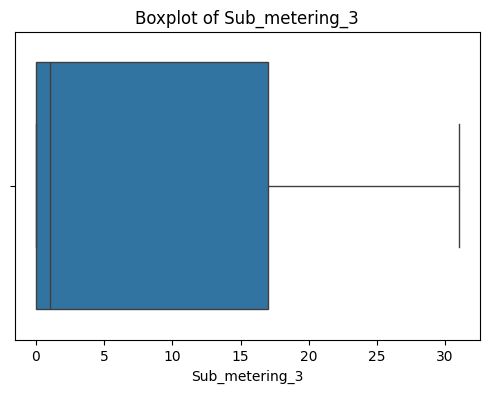

In [225]:
# Handling outliers

cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Outlier analysis states that most numerical features are right-skewed distributions with several high-value observations. These outliers are not considered noise, as they represent genuine high energy consumption events such as peak appliance usage. Therefore, instead of removing these values, they were retained to preserve the real-world characteristics of the dataset.

In [226]:
corr_matrix = df.select_dtypes(include=['number']).corr()

<Axes: >

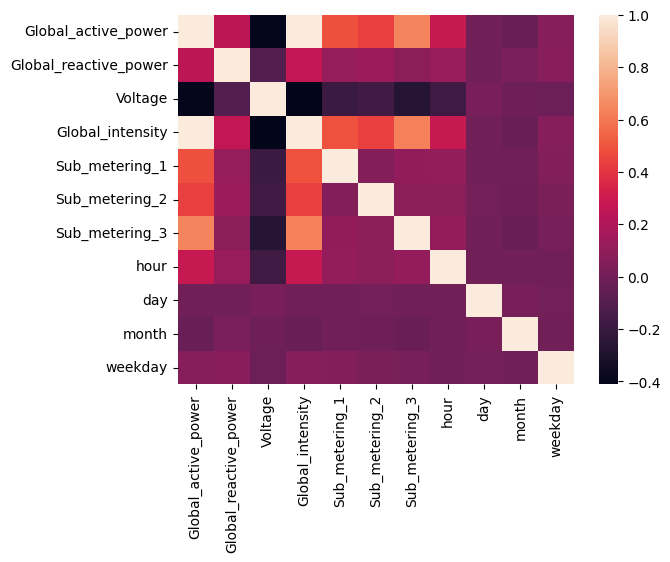

In [227]:

sns.heatmap(corr_matrix)

In [228]:
# Based on the correlation map plotted above input features are selected
X = df[[
    "Global_intensity",
    "Sub_metering_3",
    "Sub_metering_1",
    "Sub_metering_2",
    "Voltage",
    "Global_reactive_power"
]]

y = df["Global_active_power"]

**4. Data Splitting**

Distributing the data to test and train sets

In [229]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**5. Feature Scaling**

Not required because there is nomuch difference between the data values

In [230]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**6. Model Training**

Training the model using LinearRegression

In [231]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [232]:
y_pred = model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


**7. Model Evaluation**

evaluating the metrics to test performance

In [233]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2.1653877423852013
R2 Score: -3.8634391895459776


**8. Pickling the file**

In [234]:
import pickle

with open("linear_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)

**=========================================================================**

**Logistic regression**

In [235]:
# Logistic Regression

In [236]:
threshold = df["Global_active_power"].mean()

df["usage_type"] = df["Global_active_power"].apply(
    lambda x: 1 if x > threshold else 0
)

In [237]:
X = df[[
    "Global_intensity",
    "Sub_metering_3",
    "Sub_metering_1",
    "Sub_metering_2",
    "Voltage",
    "Global_reactive_power"
]]

y_class = df["usage_type"]

In [238]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42
)

In [239]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [240]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

Accuracy: 0.9959863952217364
[[235701    771]
 [   874 172510]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    236472
           1       1.00      0.99      1.00    173384

    accuracy                           1.00    409856
   macro avg       1.00      1.00      1.00    409856
weighted avg       1.00      1.00      1.00    409856



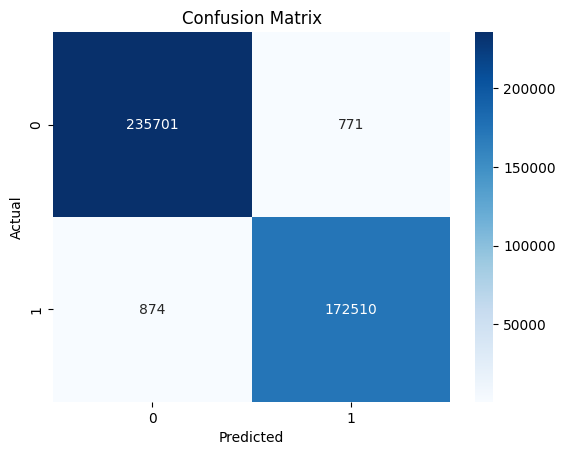

In [241]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
df["usage_type"].value_counts() #checking the class imbalance

In [243]:
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(clf, f)